# Division parameters

Here, we use a toy model of cell division to find the division parameters for the vertex model. The division parameters are chosen to reproduce the experimental volume distribution


Single cell growth:
- linear on single cell level, same for all cells?
- linear on population level (food restricted)
- Volume dependent

In [1]:
import sys
import numpy as np
import scipy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.append("utils")
import exp_io as io_exp
import ensemble_observables as ensemble

from toy_models import run_division_no_history
from vm_calibration import cell_volume_from_density
from compute_distributions import rescaled_distribution, lognorm_distribution

In [57]:
# Compare with specific density
bins = 64
density = 2000

exps_full       = io_exp.load_full_experiments()
exps_at_density = io_exp.load_experiments_at_density(exps_full, density)
V_exps = ensemble.experiment_observable(exps_at_density, "V") 

State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_A1-16_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_B1-11_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240516_A2-1_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/M

In [58]:
# Simulation parameters
Ncells = 20000      # Initial number of cells
Ntime  = 10**3      # Number of time steps
dt     = 0.0832     # Temporal resolution on division events


# Log-normal parameters
sigma = 0.3
mu   = -0.09


# Initial volume distribution
V0   = 3500         # Mean cell volume
Vstd = 0.5          # Half width of volume distribution

initial_volume_distribution = np.random.uniform(low=(1-Vstd)*V0, high=(1+Vstd)*V0, size=Ncells) #/ V0

In [59]:
# Initial parameter guess
tau   = 16                            # Approximate cell doubling time
g     = 100                           # Single cell growth
V_div = 2500                          # Division threshold
k_div = (tau * (V0 - V_div))**(-1)    # Rate coefficient. Chosen so mean rate * doubling time is 1


# Run simulation
volumes, number_of_cells, Vmean = run_division_no_history(initial_volume_distribution, Ntime, V_div=V_div, 
                                                                                              k_div=k_div,
                                                                                              g=g)

mu    = -0.0459 +/- 0.0000
sigma = 0.2874 +/- 0.0000


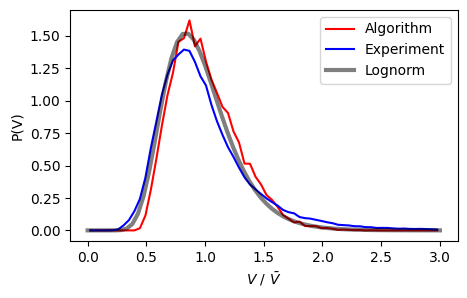

In [60]:
# Target distribution
V_arr  = np.linspace(1e-4, 3, bins)
target = lognorm_distribution(V_arr, mu, sigma)
# lognorm = lognorm_distribution(V_arr * np.exp(mu+sig**2/2), mu, sig)
exp_freq, bin_edges = np.histogram(V_exps.compressed() / np.ma.mean(V_exps), bins=bins, range=[0, 3], density=True)
exp_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])


# Compute volume distribution
freq, bin_edges = np.histogram(volumes / np.mean(volumes), range=[1e-4, 3], density=True, bins=bins)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

# Fit lognormal to data
param, popt = sc.optimize.curve_fit(lognorm_distribution, bin_centers, freq, p0=[0, 0.3])

print(f"mu    = {param[0]:0.4f} +/- {popt[0,0]:0.4f}")
print(f"sigma = {param[1]:0.4f} +/- {popt[1,1]:0.4f}")



fig, ax = plt.subplots(1, 1, figsize=(5,3))

ax.plot(bin_centers, freq,     'r-', label="Algorithm")
ax.plot(exp_centers, exp_freq, 'b-', label="Experiment")
ax.plot(V_arr, target, 'k-', lw=3, alpha=0.5, label="Lognorm")
ax.legend()


ax.set(
  xlabel=r"$V ~/~ \bar{V}$", 
  ylabel=r"P(V)"
  );


In [61]:
k_ratio = [0.5, 0.75, 1, 1.25, 1.5]
V_divs = np.linspace(1000, 3000, 10)
x_params = []

for x in k_ratio:
    V_params = []
    for V_div in V_divs:

        k_div = x/(tau * (V0 - V_div))    # Rate coefficient. Chosen so mean rate * doubling time is 1
        
        # Run simulation
        volumes, number_of_cells, Vmean = run_division_no_history(initial_volume_distribution, Ntime, V_div=V_div, 
                                                                                                      k_div=k_div,
                                                                                                      g=g)

        obs, freq   = rescaled_distribution(volumes, bins=32, hist_range=[0, 2.5])

        param, popt = sc.optimize.curve_fit(lognorm_distribution, obs, freq, p0=[-0.1, 0.3])
        V_params.append(param)

    x_params.append(np.array(V_params).T)


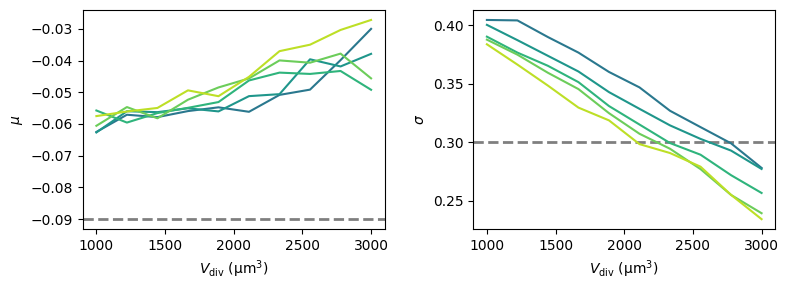

In [7]:
colors = mpl.colormaps["viridis"](np.linspace(0.4, 0.9, len(k_ratio)))
fig, ax = plt.subplots(1, 2, figsize=(8,3))

ax[0].axhline(mu,    c="k", ls="--", lw=2, alpha=0.5)
ax[1].axhline(sigma, c="k", ls="--", lw=2, alpha=0.5)

for params, c in zip(x_params, colors):
    ax[0].plot(V_divs, params[0], '-', c=c)
    ax[1].plot(V_divs, params[1], '-', c=c)


ax[0].set(
    xlabel=r"$V_{\text{div}}$ (µm$^3$)",
    ylabel=r"$\mu$"
)

ax[1].set(
    xlabel=r"$V_{\text{div}}$ (µm$^3$)",
    ylabel=r"$\sigma$"
);
fig.tight_layout()

In [62]:
Ntime  = 10**4                        # Number of time steps
tau   = 16                            # Approximate cell doubling time
g     = 150                           # Single cell growth
V_div = 2100                          # Division threshold
k_div = (tau * (V0 - V_div))**(-1)    # Rate coefficient. Chosen so mean rate * doubling time is 1
print(k_div)

# Run simulation
volumes, number_of_cells, Vmean = run_division_no_history(initial_volume_distribution, Ntime, V_div=V_div, 
                                                                                              k_div=k_div,
                                                                                              g=g)


4.464285714285714e-05


In [63]:
# Prepare arrays for plotting
time = np.arange(len(number_of_cells)) * dt

# Compute volume distribution
freq, bin_edges = np.histogram(volumes / np.mean(volumes), range=[1e-4, 3], density=True, bins=64)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

# Fit lognormal to data
param, popt = sc.optimize.curve_fit(lognorm_distribution, bin_centers, freq, p0=[0, 0.3])

print(f"mu    = {param[0]:0.4f} +/- {popt[0,0]:0.4f}")
print(f"sigma = {param[1]:0.4f} +/- {popt[1,1]:0.4f}")

exp_freq, bin_edges = np.histogram(V_exps.compressed() / np.ma.mean(V_exps), bins=bins, range=[0, 3], density=True)
exp_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

mu    = -0.0500 +/- 0.0000
sigma = 0.3396 +/- 0.0000


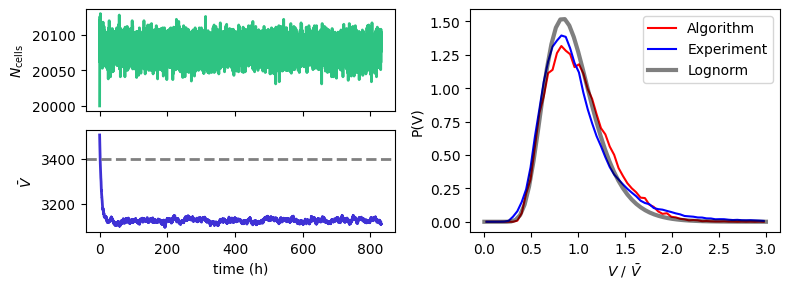

In [64]:
mosaic = [['a', 'c'],
          ['b', 'c']]

fig, ax = plt.subplot_mosaic(mosaic, figsize=(8,3))

# Plotting evolution of number of cells
ax['a'].plot(time, number_of_cells, "-", lw=2, c=(46/256, 196/256, 131/256))
ax['b'].plot(time, Vmean,           "-", lw=2, c=(63/256, 49/256, 214/256))
ax['b'].axhline(cell_volume_from_density(density), ls="dashed", c="gray", lw=2)

# ax['a'].sharex(ax['b'])
ax['a'].set(ylabel=r"$N_{\text{cells}}$",
            yscale="linear",
            xticklabels=[])
ax['b'].set(xlabel="time (h)",
            ylabel=r"$\bar{V}$")


ax['c'].plot(bin_centers, freq,     'r-', label="Algorithm")
ax['c'].plot(exp_centers, exp_freq, 'b-', label="Experiment")
ax['c'].plot(V_arr, target, 'k-', lw=3, alpha=0.5, label="Lognorm")
ax['c'].legend()
ax['c'].set(
  xlabel=r"$V ~/~ \bar{V}$", 
  ylabel=r"P(V)"
  )

fig.tight_layout()

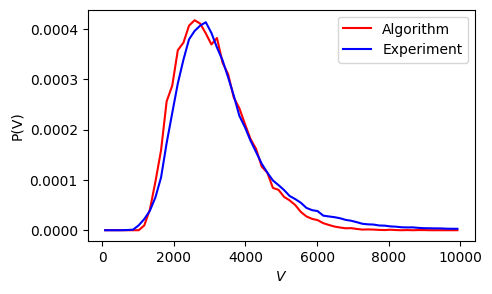

In [66]:
bins = 64

exp_freq, bin_edges = np.histogram(V_exps.compressed(), bins=bins, range=[0, 1e4], density=True)
exp_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

freq, bin_edges = np.histogram(volumes, bins=bins, range=[0, 1e4], density=True)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


fig, ax = plt.subplots(1, 1, figsize=(5,3))

ax.plot(bin_centers, freq,     'r-', label="Algorithm")
ax.plot(exp_centers, exp_freq, 'b-', label="Experiment")
ax.legend()


ax.set(
  xlabel=r"$V$", 
  ylabel=r"P(V)"
  );


## Analysis

Parameters
- $g$, growth rate: determines the convergence rate, as well as the mean volume. Any change in $g$ can be counterbalanced by changes in $k_{div}$ and $V_{div}$ and thus is not varied here.
- $k_{div}$, rate coefficient: Increasing the rate coefficient increases the probability of division for all cells, hence decreases the change of having large cells. In other words it affects the width of the distribution, and also the mean.
- $V_{div}$, division thershold: Puts a lower limit on which cells can divide. Controls mainly the mean?

In [12]:
# Simulation parameters
Ncells = 200        # Number of cells initially
Ntime  = 200        # Number of time steps
max_factor = 1000
dt     = 0.0832*2     # Temporal resolution on division events


# Initialise initial volume distribution
initial_volume_distribution = np.random.uniform(low=(1-Vstd)*V0, high=(1+Vstd)*V0, size=Ncells) # / V0


# Run division
volumes, times = run_division_with_history(initial_volume_distribution, Ntime, V_div=V_div, k_div=k_div, g=g, max_factor=max_factor)

NameError: name 'run_division_with_history' is not defined

In [ ]:
number_of_cells = np.sum(~volumes.mask, axis=1)
time = dt * np.arange(len(volumes))


# Prepare array for plot of evolution of volume distribution
density_kymograph = np.zeros([Ntime, 20])
for i in range(Ntime-1):
    obs, freq   = rescaled_distribution(volumes[i], bins=20, hist_range=[0, 2.5])
    try:
        density_kymograph[i] = (np.array(freq))
    except:
        break

obs, freq = rescaled_distribution(volumes[times-10:], bins=64, hist_range=[0, 2.5])
freq = freq / np.sum(freq)

mu = -0.0465 +/- 0.0000
mu = 0.3095 +/- 0.0000


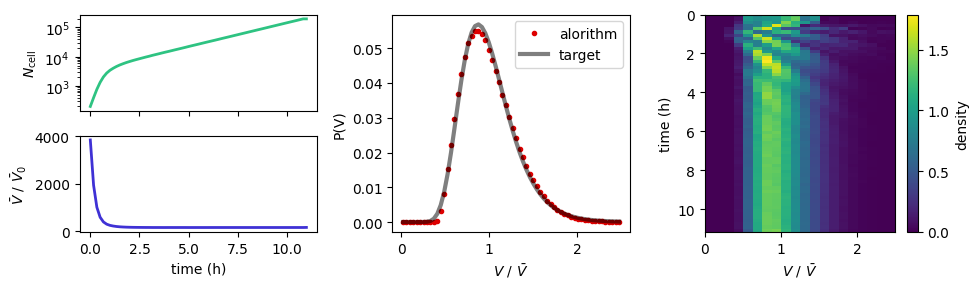

In [ ]:
mosaic = [['a', 'c', 'd'],
          ['b', 'c', 'd']]

fig, ax = plt.subplot_mosaic(mosaic, figsize=(10,3))

# Plotting evolution of number of cells
ax['a'].plot(time[number_of_cells > 0], number_of_cells[number_of_cells > 0],             "-", lw=2, c=(46/256, 196/256, 131/256))
ax['b'].plot(time[number_of_cells > 0], np.ma.mean(volumes, axis=1)[number_of_cells > 0], "-", lw=2, c=(63/256, 49/256, 214/256))

# ax['a'].sharex(ax['b'])
ax['a'].set(ylabel=r"$N_{\text{cell}}$",
            yscale="log",
            xticklabels=[])
ax['b'].set(xlabel="time (h)",
            ylabel=r"$\bar{V}~/~\bar{V}_0$")


# Plotting volume distributions

# Resulting distribution
ax['c'].plot(obs, freq, '.', lw=2, label="alorithm", c=(222/256, 0, 0))


# Lognormal fit
param, popt = sc.optimize.curve_fit(lognorm_distribution, obs, freq, p0=[0, 0.3])
# # ax['c'].plot(obs / np.exp(param[0]+param[1]**2/2), lognorm_distribution(obs, *param), 'k--', lw=2)
print(f"mu = {param[0]:0.4f} +/- {popt[0,0]:0.4f}")
print(f"mu = {param[1]:0.4f} +/- {popt[1,1]:0.4f}")
# print(param[1], popt[1,1])

# Target distribution
mu  = -0.09
sig = 0.3
lognorm = lognorm_distribution(obs * np.exp(mu+sig**2/2), mu, sig)
ax['c'].plot(obs, lognorm / np.sum(lognorm), 'k-', lw=3, alpha=0.5, label="target")
ax['c'].legend()


ax['c'].set(xlabel=r"$V ~/~ \bar{V}$", 
          ylabel=r"P(V)",
        #   xscale="log",
        #   yscale="log",
        #   xlim=(0.25, 5),
        #   ylim=(1e-4, 1e0)
          )


im = ax['d'].imshow(density_kymograph[:i], origin="upper", aspect="auto", extent=[0, 2.5, i*dt, 0])
ax['d'].set(ylabel="time (h)",
          xlabel=r"$V~/~\bar{V}$")

fig.colorbar(im, ax=ax['d'], label="density")

fig.tight_layout()
# fig.savefig("results/paper/division_algorithm.png", dpi=300)

In [ ]:
# Ntime  = 10**4        # Number of time steps

# array = np.array([0.1, 0.25, 0.5, 1, 1.5, 2, 2.5])
# params = []

# for x in array:
    
#     # Initialise initial volume distribution
#     initial_volume_distribution = np.random.uniform(low=(1-Vstd)*V0, high=(1+Vstd)*V0, size=Ncells) / V0

#     # Run simulation
#     volumes, number_of_cells, Vmean = run_division_no_history(initial_volume_distribution, Ntime, V_div=x, 
#                                                                                                   k_div=10,
#                                                                                                   g=1)

#     obs, freq   = rescaled_distribution(volumes, bins=32, hist_range=[0, 2.5])
#     freq = freq / np.sum(freq)

#     param, popt = sc.optimize.curve_fit(lognorm_distribution, obs, freq, p0=[-0.1, 0.3])

#     params.append(param)

# params = np.array(params).T

# plt.subplot(121)
# plt.plot(array, params[0], '.-')
# plt.axhline(-0.09, c="r", ls="--")


# plt.subplot(122)
# plt.plot(array, params[1], '.-')
# plt.axhline(0.305, c="r", ls="--")

# Attempt at deriving final vlume distribution from the division time distributions 

In [ ]:
def division_time_distribution_from_volume(tn, Vn0, a, b, V0=1, dt=0.0832, tauV=50):
    alpha = 1/ tauV
    a_prime = (a * alpha) / (dt * V0)
    b_prime = (a / dt) * (b - Vn0 / V0)

    density = (a_prime * tn - b_prime) * np.exp(-(a_prime / 2) * tn**2 + b_prime * tn)

    return density / np.sum(density)


def division_time_distribution_with_waiting(wn, t0, a, b, V0=1, dt=0.0832, tauV=50):
    alpha = 1 / tauV
    c = a / (V0 * dt)
    t0_ = t0 - b / alpha
    c_  = c * alpha

    density = c_ * np.exp(c_ * t0_**2 / 2) * (wn + t0_) * np.exp(-c_ * (t0_ + wn)**2 / 2)
    return density / np.sum(density)


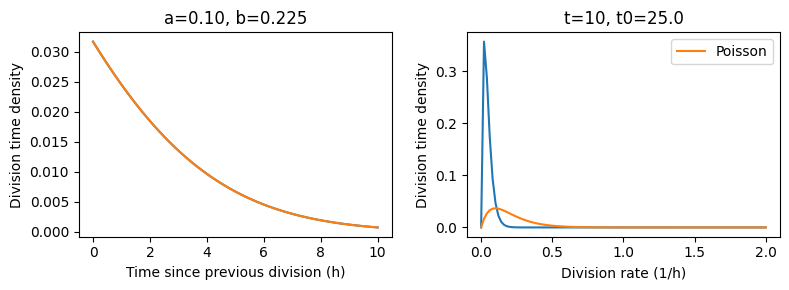

In [ ]:
# Density distribution for the first division time
tn  = np.linspace(1e-4, 10, 100)
Vn0 = V0 / 2

a = 1 / 10.5
b = 0.225
t0 = Vn0 * tauV

plt.figure(figsize=(8,3))
plt.subplot(121)
plt.title(f"a={a:0.2f}, b={b}")
plt.plot(tn, division_time_distribution_from_volume(tn, Vn0=Vn0, a=a, b=b))
plt.plot(tn, division_time_distribution_with_waiting(tn, t0=t0, a=a, b=b))
plt.xlabel("Time since previous division (h)")
plt.ylabel("Division time density");


a = np.linspace(0, 2, 100)

b  = 0.225#.225
tn = 10

plt.subplot(122)
plt.title(f"t={tn}, t0={t0}")
plt.plot(a, division_time_distribution_with_waiting(tn, t0=t0, a=a, b=b))
plt.plot(a, a * np.exp(-a*tn), label="Poisson")
plt.xlabel("Division rate (1/h)")
plt.ylabel("Division time density");
plt.legend()

plt.tight_layout()

In [ ]:
def division_time_distribution(tn, Vn0, a, b, V0=1, dt=0.0832, tauV=50, order=6):
    alpha = 1/ tauV
    a_prime = (a * alpha) / (dt * V0)
    b_prime = (a / dt) * (b - Vn0 / V0)

    density = (a_prime * tn - b_prime) * np.exp(-(a_prime / 2) * tn**2 + b_prime * tn)

    return density / np.sum(density)


def volume_after_division(division_times, Vn0=1, tauV=50, order=6, a=1/10, b=0.2):
    alpha = 1 / tauV

    for n in range(order):

        density = division_time_distribution(division_times, Vn0, a, b, order=order)
        probabilities = density[density >= 0]
        probabilities = probabilities / np.sum(probabilities)
        
        T = np.random.default_rng().choice(division_times[density >= 0], size=1, p=probabilities)

        Vn0 = 0.5 * (Vn0 + alpha * T)[0]

    return Vn0, density, division_times


def ensemble(V0=1, tauV=50, order=6, Ncells=100, a=1/10, b=0.2):
    div_times = np.linspace(1e-4, 25, 200)

    final_volume = np.zeros(Ncells)
    mean_density = np.zeros_like(div_times)

    for n in range(Ncells):
        V_after_div, density, _ = volume_after_division(div_times, Vn0=V0, tauV=tauV, order=order, a=a, b=b)

        final_volume[n] = V_after_div
        mean_density += density

    return final_volume, mean_density / Ncells, div_times


In [ ]:
# Density distribution for the first division time
tn  = np.linspace(1e-4, 20, 200)
Vn0 = V0 / 2

a = 1 / 10.5
b = 0.225
t0 = Vn0 * tauV

order = 10

final_volumes, mean_density, div_times = ensemble(V0=1, tauV=50, order=order, Ncells=10_000)

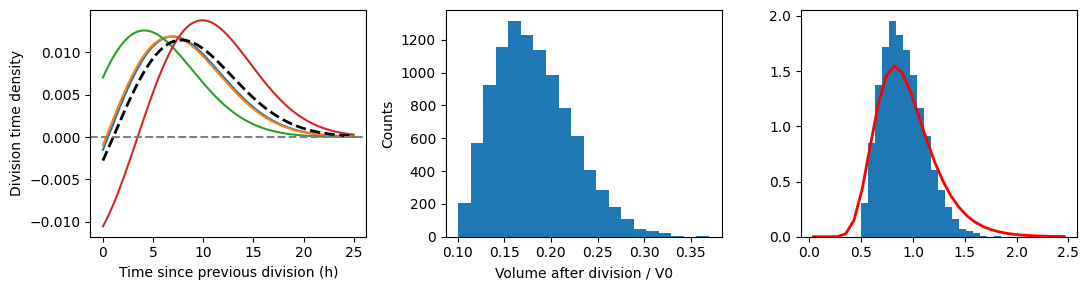

In [ ]:


plt.figure(figsize=(11, 3))
plt.subplot(131)

for i in range(4):
    V_after_div, density, div_t = volume_after_division(div_times, Vn0=V0, order=order)
    plt.plot(div_t, density)

plt.plot(div_times, mean_density, 'k--', lw=2)
plt.axhline(0, ls="--", c="gray")
plt.xlabel("Time since previous division (h)")
plt.ylabel("Division time density");
# plt.yscale("log")

plt.subplot(132)
# plt.plot(a, division_time_distribtuion_with_waiting(tn, t0=t0, a=a, b=b))
plt.hist(final_volumes, bins=20)
plt.xlabel("Volume after division / V0")
plt.ylabel("Counts");

plt.subplot(133)
plt.hist(final_volumes / 0.20, bins=20, density=True)
plt.plot(V_arr, lognorm_distribution(V_arr, -0.105, 0.3), 'r-', lw=2)

plt.tight_layout()

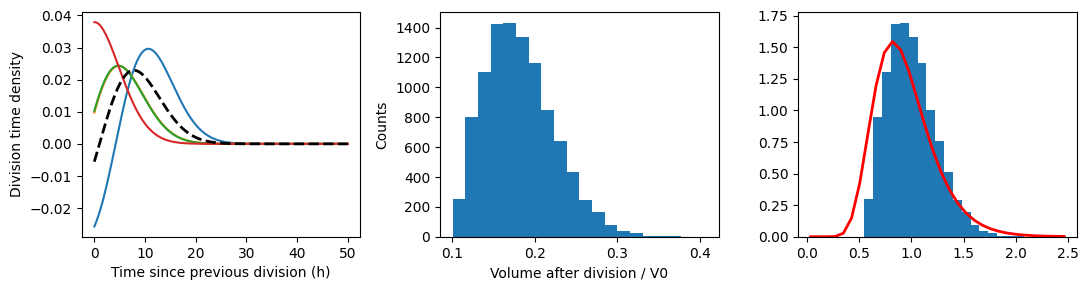

In [ ]:
order = 5

final_volumes, mean_density, div_times = ensemble(V0=1, tauV=50, order=order, Ncells=10_000)


plt.figure(figsize=(11, 3))
plt.subplot(131)

for i in range(4):
    V_after_div, density, _ = volume_after_division(div_times, Vn0=V0, order=order)
    plt.plot(div_times, density)

plt.plot(div_times, mean_density, 'k--', lw=2)
plt.xlabel("Time since previous division (h)")
plt.ylabel("Division time density");
# plt.yscale("log")

plt.subplot(132)
# plt.plot(a, division_time_distribtuion_with_waiting(tn, t0=t0, a=a, b=b))
plt.hist(final_volumes, bins=20)
plt.xlabel("Volume after division / V0")
plt.ylabel("Counts");

plt.subplot(133)
plt.hist(final_volumes / np.mean(final_volumes), bins=20, density=True)
plt.plot(V_arr, lognorm_distribution(V_arr, -0.105, 0.3), 'r-', lw=2)

plt.tight_layout()